<a href="https://colab.research.google.com/github/itagibanetos/mineracao-dados-eleitorais-2026/blob/main/02_clusterizacao_com_despesa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nesta etapa, é realizada a importação dos arquivos necessários para a análise a partir do repositório criado no GitHub.

Inicialmente, foi utilizado o comando git clone para criar uma cópia do repositório mineracao-dados-eleitorais-2026 no ambiente do Google Colab. Essa etapa é necessária porque o Colab utiliza um ambiente temporário, ou seja, os arquivos podem deixar de estar disponíveis quando a sessão é encerrada ou reiniciada.

Em seguida, é usado o comando %cd para acessar a pasta do repositório clonada no caminho /content/mineracao-dados-eleitorais-2026. A partir desse momento, é possível utilizar caminhos relativos para acessar os arquivos do projeto, como a pasta dados.

Por fim, é executado o comando !ls dados para listar os arquivos presentes nessa pasta. Dessa forma, pude verificar se os arquivos de dados necessários para as etapas seguintes da análise estavam disponíveis corretamente no ambiente do Colab.

In [2]:
#Importa os arquivos salvos no diretório do Github

!git clone https://github.com/itagibanetos/mineracao-dados-eleitorais-2026.git
%cd /content/mineracao-dados-eleitorais-2026

!ls dados

Cloning into 'mineracao-dados-eleitorais-2026'...
remote: Enumerating objects: 98, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 98 (delta 30), reused 12 (delta 12), pack-reused 45 (from 1)
Receiving objects: 100% (98/98), 30.58 MiB | 17.48 MiB/s, done.
Resolving deltas: 100% (41/41), done.
/content/mineracao-dados-eleitorais-2026
 bem_candidato_2026.zip
 candidatos_deputado_federal_PR_RS_SC_2026_com_despesas.csv
'candidatos_DEPUTADO_FEDERAL_['\''PR'\'', '\''RS'\'', '\''SC'\'']_2026.csv'
 consulta_cand_2026.zip
 prestacao_de_contas_eleitorais_candidatos_2026.zip


O código carrega a base de candidatos a Deputado Federal de PR, RS e SC, extrai do arquivo ZIP apenas os arquivos de despesas contratadas desses estados e processa os dados em partes para reduzir o uso de memória.

Em seguida, filtra as despesas do cargo analisado, soma o gasto contratado e conta a quantidade de despesas de cada candidato. Esses dados são unidos à base principal por meio do identificador `SQ_CANDIDATO`.

Por fim, o código cria as colunas de gasto total, quantidade de despesas, indicação de existência de despesa e gasto em escala logarítmica. A base consolidada é salva em um novo arquivo CSV para ser utilizada nas análises posteriores.

In [3]:
from pathlib import Path
from zipfile import ZipFile
import pandas as pd
import numpy as np

# =========================
# 1. Caminhos dos arquivos
# =========================
PASTA_DADOS = Path("dados")
PASTA_EXTRAIDOS = PASTA_DADOS / "extraidos_despesas"

ARQUIVO_CANDIDATOS = (
    PASTA_DADOS / "candidatos_DEPUTADO_FEDERAL_['PR', 'RS', 'SC']_2026.csv"
)

ARQUIVO_ZIP = (
    PASTA_DADOS / "prestacao_de_contas_eleitorais_candidatos_2026.zip"
)

ARQUIVO_SAIDA = (
    PASTA_DADOS / "candidatos_deputado_federal_PR_RS_SC_2026_com_despesas.csv"
)

ESTADOS = ["PR", "RS", "SC"]

# =============================================
# 2. Lê a base principal dos candidatos
# =============================================
candidatos = pd.read_csv(
    ARQUIVO_CANDIDATOS,
    sep=",",
    dtype={"SQ_CANDIDATO": "string"},
    low_memory=False
)

candidatos = candidatos[
    candidatos["DS_CARGO"].str.upper().eq("DEPUTADO FEDERAL")
].copy()

# =========================================================
# 3. Localiza e descompacta somente os CSVs necessários
# =========================================================
PASTA_EXTRAIDOS.mkdir(parents=True, exist_ok=True)

arquivos_esperados = {
    f"despesas_contratadas_candidatos_2026_{uf}.csv".lower()
    for uf in ESTADOS
}

with ZipFile(ARQUIVO_ZIP, "r") as zip_ref:
    arquivos_selecionados = [
        arquivo
        for arquivo in zip_ref.namelist()
        if Path(arquivo).name.lower() in arquivos_esperados
    ]

    if len(arquivos_selecionados) != len(ESTADOS):
        raise FileNotFoundError(
            "Não encontrei os arquivos de despesas contratadas "
            "de PR, RS e SC dentro do ZIP."
        )

    arquivos_extraidos = [
        Path(zip_ref.extract(arquivo, PASTA_EXTRAIDOS))
        for arquivo in arquivos_selecionados
    ]

# =====================================================================
# 4. Processa os arquivos grandes em partes e soma por candidato
# =====================================================================
parciais = []

for arquivo in arquivos_extraidos:
    print(f"Processando: {arquivo.name}")

    leitor = pd.read_csv(
        arquivo,
        sep=";",
        encoding="latin1",
        usecols=[
            "DS_CARGO",
            "SQ_CANDIDATO",
            "SQ_DESPESA",
            "VR_DESPESA_CONTRATADA"
        ],
        dtype={
            "DS_CARGO": "string",
            "SQ_CANDIDATO": "string",
            "SQ_DESPESA": "string",
            "VR_DESPESA_CONTRATADA": "string"
        },
        chunksize=200_000,
        low_memory=False
    )

    for parte in leitor:
        parte = parte[
            parte["DS_CARGO"].str.upper().eq("DEPUTADO FEDERAL")
        ].copy()

        parte["VR_DESPESA_CONTRATADA"] = pd.to_numeric(
            parte["VR_DESPESA_CONTRATADA"]
            .str.replace(".", "", regex=False)
            .str.replace(",", ".", regex=False),
            errors="coerce"
        ).fillna(0)

        parcial = (
            parte
            .groupby("SQ_CANDIDATO", as_index=False)
            .agg(
                Total_Gasto_Campanha=(
                    "VR_DESPESA_CONTRATADA", "sum"
                ),
                QTD_DESPESAS_CONTRATADAS=(
                    "SQ_DESPESA", "count"
                )
            )
        )

        parciais.append(parcial)

# Consolida PR, RS e SC
totais_despesas = (
    pd.concat(parciais, ignore_index=True)
    .groupby("SQ_CANDIDATO", as_index=False)
    .agg(
        Total_Gasto_Campanha=(
            "Total_Gasto_Campanha", "sum"
        ),
        QTD_DESPESAS_CONTRATADAS=(
            "QTD_DESPESAS_CONTRATADAS", "sum"
        )
    )
)

# =====================================================
# 5. Une os gastos ao arquivo principal de candidatos
# =====================================================
resultado = candidatos.merge(
    totais_despesas,
    on="SQ_CANDIDATO",
    how="left"
)

resultado["TEM_DESPESA_CONTRATADA"] = (
    resultado["Total_Gasto_Campanha"].notna()
)

resultado["Total_Gasto_Campanha"] = (
    resultado["Total_Gasto_Campanha"].fillna(0)
)

resultado["QTD_DESPESAS_CONTRATADAS"] = (
    resultado["QTD_DESPESAS_CONTRATADAS"].fillna(0).astype(int)
)

# Nova variável com transformação logarítmica
resultado["Total_Gasto_Campanha_Log"] = np.log1p(
    resultado["Total_Gasto_Campanha"]
)

# ======================================
# 6. Gera o CSV para as novas análises
# ======================================
resultado.to_csv(
    ARQUIVO_SAIDA,
    index=False,
    encoding="utf-8-sig"
)

print(f"Arquivo criado: {ARQUIVO_SAIDA}")
display(
    resultado[
        [
            "SG_UF",
            "NM_CANDIDATO",
            "Total_Gasto_Campanha",
            "Total_Gasto_Campanha_Log",
            "QTD_DESPESAS_CONTRATADAS"
        ]
    ].head()
)

Processando: despesas_contratadas_candidatos_2026_PR.csv
Processando: despesas_contratadas_candidatos_2026_RS.csv
Processando: despesas_contratadas_candidatos_2026_SC.csv
Arquivo criado: dados/candidatos_deputado_federal_PR_RS_SC_2026_com_despesas.csv


,SG_UF,NM_CANDIDATO,Total_Gasto_Campanha,Total_Gasto_Campanha_Log,QTD_DESPESAS_CONTRATADAS
0,PR,MARIO SETO TAKEGUMA JUNIOR,34140.0,10.438254,16
1,PR,ANTÔNIO FERNANDO TEIGAO,59862.86,10.999828,35
2,PR,CAMILLA DE MORAES GONDA,283738.41,12.555812,59
3,PR,CHARLESTON ROBERTO DE OLIVEIRA MAYER JUNIOR,0.0,0.0,1
4,PR,OMAR RAIMUNDO PICHETH NETO,144017.53,11.877697,48


O código carrega a base consolidada de candidatos com as despesas de campanha e transforma a variável de escolaridade em anos de estudo, utilizando uma tabela de correspondência entre cada nível de instrução e sua quantidade estimada de anos de estudo.

Em seguida, seleciona as variáveis `IDADE`, `ANOS_ESTUDO`, `Total_Bens_Log` e `Total_Gasto_Campanha_Log` para a nova análise. Os registros com valores ausentes, inválidos ou sem informação de escolaridade são removidos.

Depois, as variáveis são padronizadas para que tenham a mesma escala e nenhuma delas exerça influência maior apenas por possuir valores numericamente mais altos.

O código executa o algoritmo K-means para diferentes quantidades de clusters, variando de 2 a 19 grupos. Para cada valor de `k`, calcula o WCSS, utilizado no método do cotovelo, e o índice silhouette, utilizado para avaliar a separação entre os clusters.

Por fim, são gerados um gráfico comparando o cotovelo e o silhouette, uma tabela com os resultados e uma listagem dos valores calculados para cada quantidade de clusters. Esses resultados permitem verificar se a inclusão do gasto de campanha altera a quantidade mais adequada de clusters para a análise.

Candidatos sem correspondência de escolaridade: 0
Registros utilizados na análise: 1,117


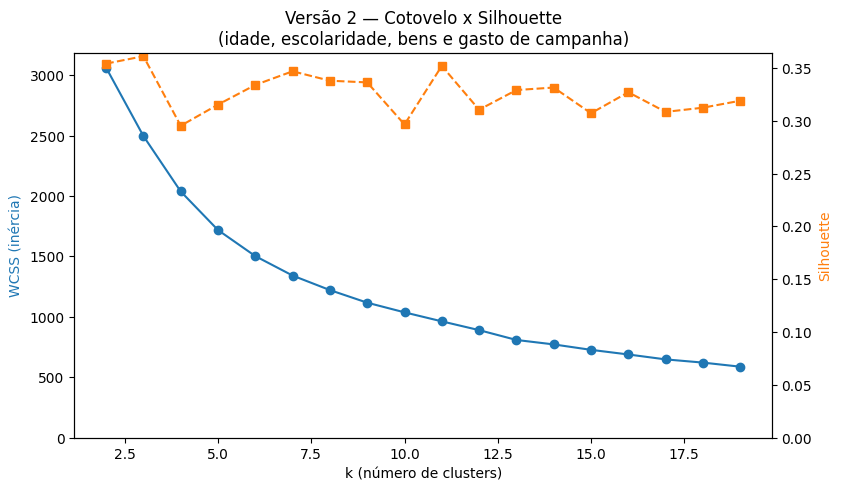

,k,WCSS,Silhouette
0,2,3062.103436,0.354206
1,3,2496.535013,0.361250
2,4,2037.956545,0.295375
3,5,1718.380490,0.315409
4,6,1502.773229,0.334056
5,7,1341.770642,0.346961
6,8,1221.716148,0.338039
7,9,1117.419772,0.336439
8,10,1037.491754,0.296613
9,11,962.996813,0.352052


k=2 | WCSS=3062.103 | silhouette=0.354
k=3 | WCSS=2496.535 | silhouette=0.361
k=4 | WCSS=2037.957 | silhouette=0.295
k=5 | WCSS=1718.380 | silhouette=0.315
k=6 | WCSS=1502.773 | silhouette=0.334
k=7 | WCSS=1341.771 | silhouette=0.347
k=8 | WCSS=1221.716 | silhouette=0.338
k=9 | WCSS=1117.420 | silhouette=0.336
k=10 | WCSS=1037.492 | silhouette=0.297
k=11 | WCSS=962.997 | silhouette=0.352
k=12 | WCSS=890.348 | silhouette=0.311
k=13 | WCSS=808.968 | silhouette=0.329
k=14 | WCSS=772.115 | silhouette=0.332
k=15 | WCSS=727.239 | silhouette=0.307
k=16 | WCSS=688.865 | silhouette=0.327
k=17 | WCSS=648.219 | silhouette=0.309
k=18 | WCSS=621.673 | silhouette=0.312
k=19 | WCSS=587.833 | silhouette=0.319


In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

SEMENTE = 42

# Arquivo gerado na etapa anterior
ARQUIVO_DADOS = Path(
    "dados/candidatos_deputado_federal_PR_RS_SC_2026_com_despesas.csv"
)

# Carrega a base
df = pd.read_csv(
    ARQUIVO_DADOS,
    encoding="utf-8-sig",
    low_memory=False
)

# Converte escolaridade em anos de estudo
ANOS_ESTUDO_POR_GRAU = {
    "ANALFABETO": 0,
    "LÊ E ESCREVE": 1,
    "ENSINO FUNDAMENTAL INCOMPLETO": 4,
    "ENSINO FUNDAMENTAL COMPLETO": 8,
    "ENSINO MÉDIO INCOMPLETO": 9,
    "ENSINO MÉDIO COMPLETO": 11,
    "SUPERIOR INCOMPLETO": 13,
    "SUPERIOR COMPLETO": 16,
}

df["ANOS_ESTUDO"] = (
    df["DS_GRAU_INSTRUCAO"]
    .astype("string")
    .str.strip()
    .str.upper()
    .map(ANOS_ESTUDO_POR_GRAU)
)

print(
    "Candidatos sem correspondência de escolaridade:",
    df["ANOS_ESTUDO"].isna().sum()
)

# Variáveis da nova análise
variaveis_v2 = [
    "IDADE",
    "ANOS_ESTUDO",
    "Total_Bens_Log",
    "Total_Gasto_Campanha_Log"
]

# Remove registros sem informação suficiente para a clusterização
dados_v2 = (
    df[variaveis_v2]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy()
)

print(f"Registros utilizados na análise: {len(dados_v2):,}")

# Padroniza as variáveis
scaler_v2 = StandardScaler()
X_v2 = scaler_v2.fit_transform(dados_v2)

# Testa valores de k entre 2 e 19
wcss_v2, sil_v2 = [], []
faixa_k = range(2, 20)

for k in faixa_k:
    km = KMeans(
        n_clusters=k,
        random_state=SEMENTE,
        n_init=10
    )

    labels = km.fit_predict(X_v2)

    wcss_v2.append(km.inertia_)
    sil_v2.append(silhouette_score(X_v2, labels))

# Gráfico de cotovelo e silhouette
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(
    list(faixa_k),
    wcss_v2,
    marker="o",
    color="tab:blue"
)

ax1.set_xlabel("k (número de clusters)")
ax1.set_ylabel("WCSS (inércia)", color="tab:blue")
ax1.set_ylim(bottom=0)
ax1.set_title(
    "Versão 2 — Cotovelo x Silhouette\n"
    "(idade, escolaridade, bens e gasto de campanha)"
)

ax2 = ax1.twinx()

ax2.plot(
    list(faixa_k),
    sil_v2,
    marker="s",
    linestyle="--",
    color="tab:orange"
)

ax2.set_ylabel("Silhouette", color="tab:orange")
ax2.set_ylim(bottom=min(0, min(sil_v2)))

plt.show()

# Tabela com os resultados
resultado_k_v2 = pd.DataFrame({
    "k": list(faixa_k),
    "WCSS": wcss_v2,
    "Silhouette": sil_v2
})

display(resultado_k_v2)

for k, w, s in zip(faixa_k, wcss_v2, sil_v2):
    print(f"k={k} | WCSS={w:.3f} | silhouette={s:.3f}")

O código aplica o algoritmo K-means utilizando a quantidade final de clusters definida a partir da análise anterior de cotovelo e silhouette. Neste caso, foi utilizado k = 5, formando cinco grupos de candidatos.

Inicialmente, são recuperados apenas os registros que foram utilizados na etapa de padronização das variáveis. Isso garante que a clusterização seja aplicada exatamente aos candidatos que possuem informações completas de idade, escolaridade, patrimônio e gasto de campanha.

Em seguida, o algoritmo K-means é executado sobre a matriz padronizada X_v2. O resultado atribui um número de cluster a cada candidato. Esses números são convertidos em letras, de modo que os grupos passem a ser identificados como Cluster A, Cluster B, Cluster C, Cluster D e Cluster E.

Também é criada uma paleta fixa de cores para os clusters. Essa paleta será reutilizada nos gráficos posteriores, permitindo que cada cluster mantenha a mesma cor durante toda a análise.

Por fim, o código calcula e exibe a quantidade de candidatos presente em cada cluster, além de informar o valor de k escolhido e o total de candidatos utilizados na clusterização.

In [5]:
import seaborn as sns
from sklearn.cluster import KMeans

# Escolha o k definido a partir do gráfico anterior
# Exemplo: mantenha 5 apenas se esse continuar sendo o melhor valor identificado
k_final_v2 = 7

# Recupera os registros usados para criar X_v2
df_cluster_v2 = df.loc[dados_v2.index].copy()

# Aplica K-means às variáveis padronizadas
kmeans_v2 = KMeans(
    n_clusters=k_final_v2,
    random_state=SEMENTE,
    n_init=10
)

df_cluster_v2["cluster"] = kmeans_v2.fit_predict(X_v2)

# Troca 0, 1, 2... por A, B, C...
df_cluster_v2["cluster"] = df_cluster_v2["cluster"].map(
    lambda x: chr(65 + x)
)

# Paleta fixa para os gráficos seguintes
clusters_ordenados_v2 = sorted(df_cluster_v2["cluster"].unique())

cores_cluster_v2 = dict(
    zip(
        clusters_ordenados_v2,
        sns.color_palette(
            "Set2",
            n_colors=len(clusters_ordenados_v2)
        )
    )
)

# Quantidade de candidatos por cluster
resumo_clusters_v2 = (
    df_cluster_v2["cluster"]
    .value_counts()
    .sort_index()
    .rename("Quantidade de candidatos")
)

display(resumo_clusters_v2)

print(f"K escolhido: {k_final_v2}")
print(f"Total de candidatos clusterizados: {len(df_cluster_v2):,}")

,Quantidade de candidatos
cluster,
A,101
B,254
C,131
D,54
E,183
F,306
G,88


K escolhido: 7
Total de candidatos clusterizados: 1,117


O código gera um resumo estatístico para interpretar as características de cada cluster criado pelo algoritmo K-means.

Para cada grupo, são calculados a quantidade de candidatos, a idade média, a média de anos de estudo, o patrimônio mediano, o gasto mediano e médio de campanha, além do percentual de candidatos sem gastos contratados registrados. Os valores são arredondados para uma casa decimal, facilitando a leitura e a comparação entre os clusters.

Em seguida, o código recupera os centróides gerados pelo K-means. Como o algoritmo foi aplicado sobre dados padronizados, os centróides inicialmente estão em uma escala transformada. Por esse motivo, é aplicada a transformação inversa utilizando o `scaler_v2`.

Após essa transformação, os centróides voltam a representar as escalas utilizadas nas variáveis originais: idade, anos de estudo, patrimônio em escala logarítmica e gasto de campanha em escala logarítmica.

Por fim, os centróides recebem as identificações A, B, C, D e E e são apresentados em uma tabela. Essa tabela permite comparar o perfil médio de cada cluster nas quatro variáveis utilizadas pela clusterização.

In [6]:
# Resumo interpretável de cada cluster
resumo_driver_v2 = (
    df_cluster_v2
    .groupby("cluster")
    .agg(
        qtd_candidatos=("SQ_CANDIDATO", "count"),
        idade_media=("IDADE", "mean"),
        anos_estudo_medio=("ANOS_ESTUDO", "mean"),
        patrimonio_mediano=("Total_Bens", "median"),
        gasto_campanha_mediano=("Total_Gasto_Campanha", "median"),
        gasto_campanha_medio=("Total_Gasto_Campanha", "mean"),
        pct_sem_gasto_contratado=(
            "Total_Gasto_Campanha",
            lambda serie: (serie == 0).mean() * 100
        )
    )
    .round(1)
)

display(resumo_driver_v2)

# Centróides nas escalas originais das quatro variáveis usadas no K-means
centroides_norm_v2 = kmeans_v2.cluster_centers_

centroides_naturais_v2 = scaler_v2.inverse_transform(
    centroides_norm_v2
)

df_centroides_v2 = pd.DataFrame(
    centroides_naturais_v2,
    columns=variaveis_v2
)

df_centroides_v2.index = [
    chr(65 + i) for i in range(k_final_v2)
]

df_centroides_v2.index.name = "cluster"

display(df_centroides_v2.round(2))

,qtd_candidatos,idade_media,anos_estudo_medio,patrimonio_mediano,gasto_campanha_mediano,gasto_campanha_medio,pct_sem_gasto_contratado
cluster,,,,,,,
A,101,48.8,14.0,185000.0,0.0,4.5,96.0
B,254,61.7,15.7,797677.6,138207.9,430985.6,0.0
C,131,48.1,11.2,265000.0,44099.0,155632.4,0.0
D,54,54.9,6.2,0.0,0.0,6372.9,61.1
E,183,44.3,13.6,0.0,28060.0,80659.9,0.0
F,306,40.3,15.7,295142.4,69069.6,327156.1,0.0
G,88,45.1,13.0,0.0,0.0,0.7,94.3


,IDADE,ANOS_ESTUDO,Total_Bens_Log,Total_Gasto_Campanha_Log
cluster,,,,
A,48.76,13.99,11.92,0.18
B,61.68,15.66,13.53,11.80
C,48.10,11.16,12.17,10.59
D,54.93,6.19,3.14,3.30
E,44.32,13.61,0.09,10.16
F,40.35,15.75,12.52,11.22
G,45.08,13.03,0.13,0.08


O código permite definir manualmente a quantidade de clusters que será utilizada na análise por meio da variável `K_FINAL`. Após informar esse valor, o algoritmo K-means é executado novamente utilizando as variáveis padronizadas de idade, anos de estudo, patrimônio e gasto de campanha.

Os candidatos utilizados na clusterização são organizados em grupos identificados por letras, como Cluster A, Cluster B, Cluster C e assim por diante. Também é criada uma paleta de cores fixa para que cada cluster mantenha a mesma cor nos gráficos gerados.

Em seguida, o código recupera os centróides de cada cluster e normaliza seus valores entre 0 e 1. Essa normalização é necessária para permitir a comparação visual das variáveis no gráfico de radar, pois elas possuem escalas diferentes.

Por fim, são gerados dois tipos de visualização: um gráfico de radar com todos os clusters sobrepostos e gráficos individuais para cada cluster. O código também exibe a quantidade de candidatos presente em cada grupo formado.

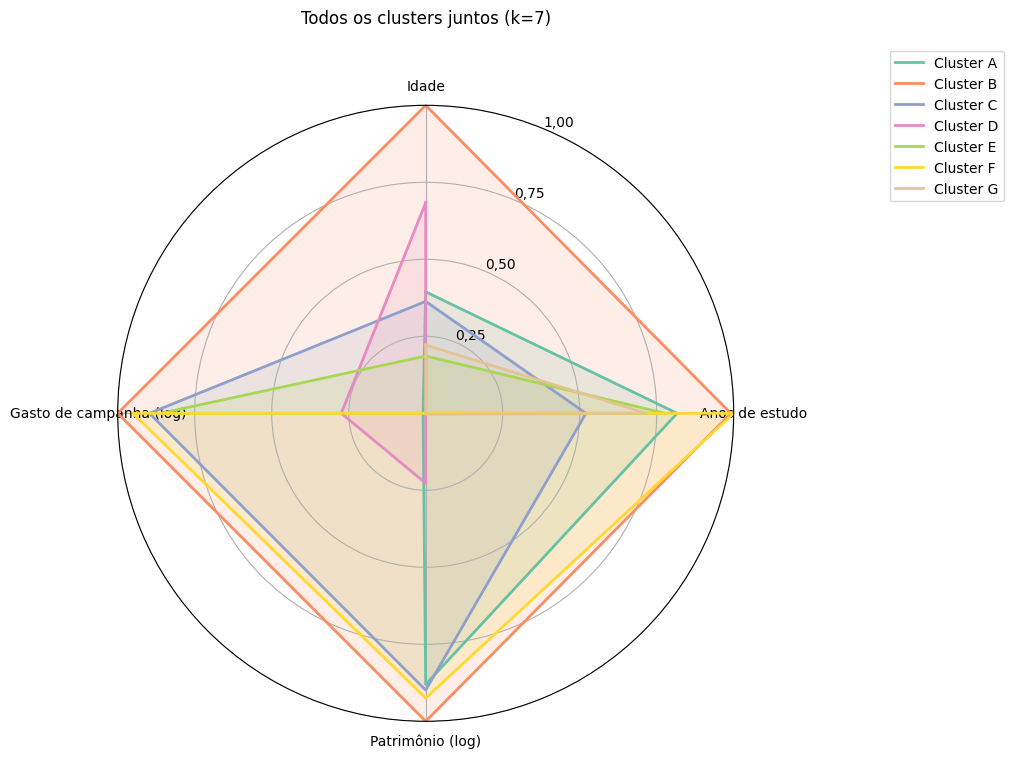

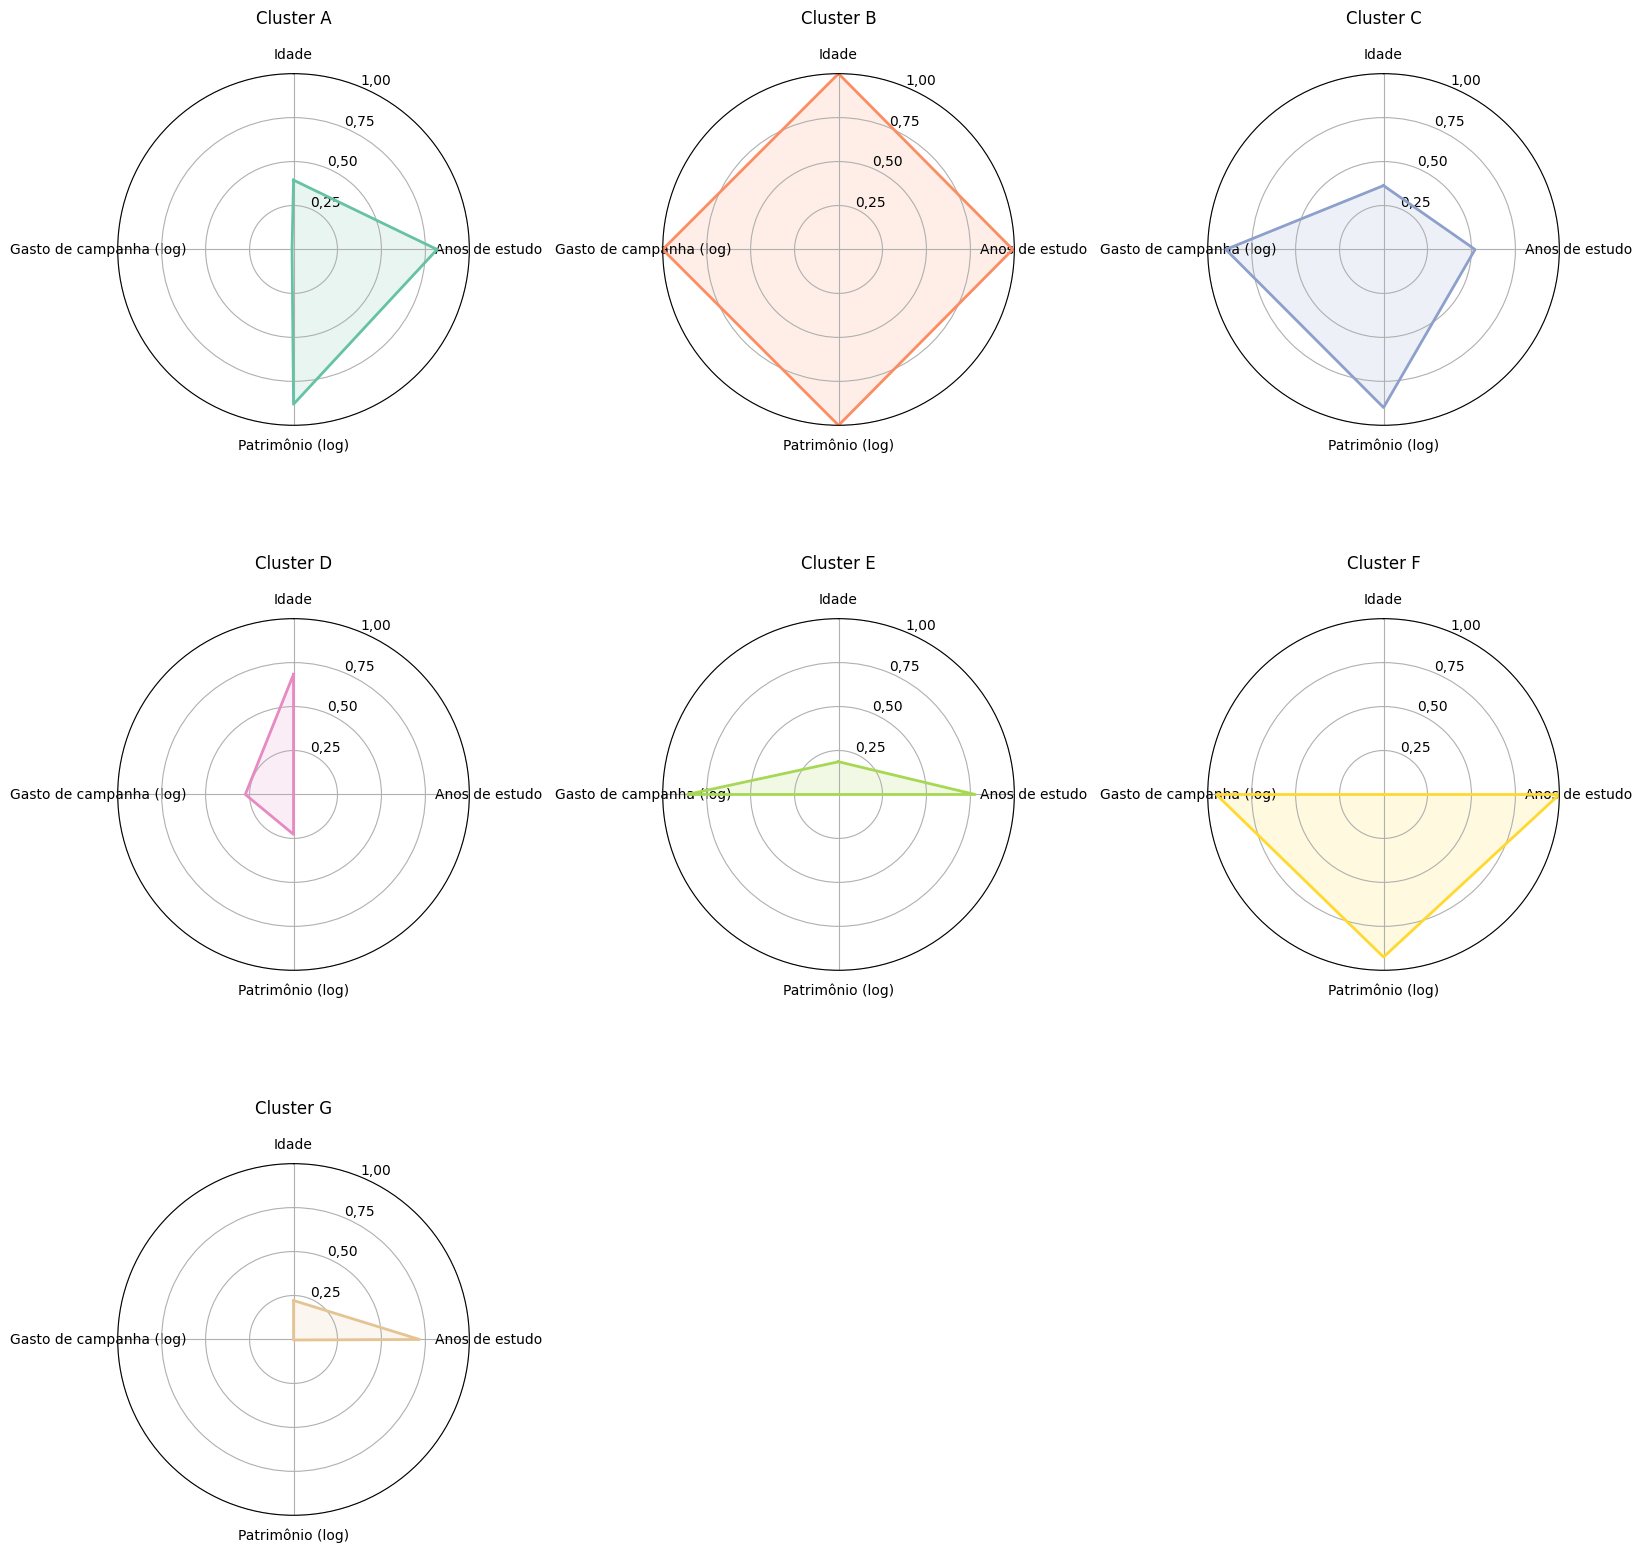

,Quantidade de candidatos
cluster,
A,101
B,254
C,131
D,54
E,183
F,306
G,88


In [10]:
from math import pi

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# ==================================================
# Informe aqui a quantidade de clusters desejada
# ==================================================
K_FINAL = 7

if K_FINAL < 2 or K_FINAL > len(dados_v2):
    raise ValueError("Informe um valor de K entre 2 e a quantidade de registros.")

# Recupera os candidatos utilizados na clusterização
df_cluster_v2 = df.loc[dados_v2.index].copy()

# Aplica novamente o K-means com o K informado
kmeans_v2 = KMeans(
    n_clusters=K_FINAL,
    random_state=SEMENTE,
    n_init=10
)

df_cluster_v2["cluster"] = kmeans_v2.fit_predict(X_v2)

# Converte os números dos clusters em letras: A, B, C...
df_cluster_v2["cluster"] = df_cluster_v2["cluster"].map(
    lambda x: chr(65 + x)
)

clusters_ordenados_v2 = sorted(df_cluster_v2["cluster"].unique())

# Define uma cor fixa para cada cluster
cores_cluster_v2 = dict(
    zip(
        clusters_ordenados_v2,
        sns.color_palette(
            "Set2",
            n_colors=K_FINAL
        )
    )
)

# Centróides originais das variáveis usadas no K-means
centroides_norm_v2 = kmeans_v2.cluster_centers_

centroides_naturais_v2 = scaler_v2.inverse_transform(
    centroides_norm_v2
)

# Normaliza os centróides entre 0 e 1 somente para o gráfico radar
scaler_radar_v2 = MinMaxScaler()

centros_radar_v2 = scaler_radar_v2.fit_transform(
    centroides_naturais_v2
)

labels_eixos_v2 = [
    "Idade",
    "Anos de estudo",
    "Patrimônio (log)",
    "Gasto de campanha (log)"
]

# Função para criar o gráfico radar
def plot_radar(ax, centros, labels_eixos, labels_series, cores, titulo):
    n_eixos = len(labels_eixos)

    angulos = [
        n / float(n_eixos) * 2 * pi
        for n in range(n_eixos)
    ]

    angulos += angulos[:1]

    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)

    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(labels_eixos)

    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.50, 0.75, 1.00])
    ax.set_yticklabels(["0,25", "0,50", "0,75", "1,00"])

    for i, linha in enumerate(centros):
        valores = list(linha) + [linha[0]]
        cor = cores[labels_series[i]]

        ax.plot(
            angulos,
            valores,
            linewidth=2,
            label=f"Cluster {labels_series[i]}",
            color=cor
        )

        ax.fill(
            angulos,
            valores,
            alpha=0.15,
            color=cor
        )

    ax.set_title(titulo, y=1.12)


# ==================================================
# Radar com todos os clusters
# ==================================================
fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw=dict(polar=True)
)

plot_radar(
    ax,
    centros_radar_v2,
    labels_eixos_v2,
    clusters_ordenados_v2,
    cores_cluster_v2,
    f"Todos os clusters juntos (k={K_FINAL})"
)

ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.45, 1.10)
)

plt.show()


# ==================================================
# Um gráfico radar para cada cluster
# ==================================================
ncols = min(K_FINAL, 3)
nrows = -(-K_FINAL // ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5.5 * ncols, 5.5 * nrows),
    subplot_kw=dict(polar=True)
)

axes = np.atleast_1d(axes).ravel()

for i, cluster in enumerate(clusters_ordenados_v2):
    plot_radar(
        axes[i],
        [centros_radar_v2[i]],
        labels_eixos_v2,
        [cluster],
        cores_cluster_v2,
        f"Cluster {cluster}"
    )

# Remove espaços vazios do gráfico
for j in range(len(clusters_ordenados_v2), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# Quantidade de candidatos em cada cluster
display(
    df_cluster_v2["cluster"]
    .value_counts()
    .sort_index()
    .rename("Quantidade de candidatos")
)

**A pergunta de verdade: incluir Total_Gasto_Campanha_Log como uma 4ª variável-driver (junto com IDADE, ANOS_ESTUDO, Total_Bens_Log) muda os clusters da Fase 2? Quem gasta mais é o mesmo grupo dos Abastados, ou gasto de campanha é uma dimensão diferente de patrimônio pessoal?**

A inclusão de Gastos de Campanha como quarta variável-driver altera os clusters da Fase 2, porque introduz uma dimensão que não se confunde totalmente com patrimônio. Embora exista correlação parcial entre riqueza e gasto, os gráficos mostram que há grupos que gastam muito sem serem os mais abastados. Portanto, gasto de campanha é uma dimensão diferente de patrimônio pessoal e contribui para redefinir os perfis dos clusters.